# SMART-BP Blood Pressure Image Transcription

In [1]:
import os
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, Image

In [2]:
class Box:

  """
  Represents a single detected bounding box from YOLO output.
  
  Attributes:
      coordinate : [x1, y1, x2, y2] bounding box coordinates
      confidence : detection confidence score
      classId    : predicted class index
      names      : class label mapping
  """
    
  def __init__(self, coordinate, confidence, classId, names):
    self.coordinate = coordinate
    self.x1 = coordinate[0] #left
    self.y1 = coordinate[1] #top
    self.x2 = coordinate[2] #right
    self.y2 = coordinate[3] #bottom
    self.confidence = float(confidence)
    self.classId = classId
    self.names = names

  def className(self):
    # Returns human-readable class label (e.g., digit "5", etc.)
    return self.names[int(self.classId)] 

  def width(self):
    # Width of bounding box
    return self.x2 - self.x1

  def height(self):
    # Height of bounding box
    return self.y2 - self.y1

  def area(self):
    # Area used for filtering or prioritizing detections
    return self.width() * self.height()

  def isInside(self, otherBox):
    x1Intersection = max(otherBox.x1, self.x1)
    y1Intersection = max(otherBox.y1, self.y1)
    x2Intersection = min(otherBox.x2, self.x2)
    y2Intersection = min(otherBox.y2, self.y2)
    widthIntersection = max(0, x2Intersection - x1Intersection)
    heightIntersection = max(0, y2Intersection - y1Intersection)
    intersection_area = widthIntersection * heightIntersection

    if self.area() <= 0:
        return False
        
    return (intersection_area / self.area() > 0.75)

In [3]:
class BoxCollection:
  
  """
  Stores a group of digit bounding boxes corresponding to a single BP value
  (e.g., systolic, diastolic, or pulse).
  """
    
  def __init__(self):
    self.digits = []    # array of BoundingBox objects
    self.value = 0      ## reconstructed numeric value

  def sortDigit(self): 
      
    """
    Sort digits from left to right based on x-coordinate.
    """
      
    n = len(self.digits)
    for i in range(n-1):
      swapped = False
      for j in range(0, n-i-1):
        if self.digits[j].x1 > self.digits[j + 1].x1:
          swapped = True
          self.digits[j], self.digits[j + 1] = self.digits[j + 1], self.digits[j]
      if not swapped:
        return    # haven't needed to make a single swap

  def getValue(self):
    self.sortDigit()
    concatDigit = ''
    for digit in self.digits:
      if (digit.className() != "10"):
        concatDigit += digit.className()
    if (concatDigit != ''):
      self.value = int(concatDigit)
    return self.value

  def get10Box(self):
    for digit in self.digits:
      if (digit.className() == "10"):
        return digit
    return

In [4]:
class BPValues:
    
    """
    Stores extracted BP measurements:
    - Systolic (SYS)
    - Diastolic (DIA)
    - Pulse (PUL)

    """
    
    def __init__(self):
        self.values = []

    def sys(self):
        try:
          return self.values[0].getValue()
        except IndexError:
          return "-"

    def dia(self):
        try:
          return self.values[1].getValue()
        except IndexError:
          return "-"

    def pul(self):
        try:
          return self.values[2].getValue()
        except IndexError:
          return "-"

    def identifyValueType(self):
        
        """
        Assign values purely by vertical position:
          Top    -> SYS
          Middle -> DIA
          Bottom -> PUL
        Works even if only 1 or 2 values are detected.
        """
    
        if len(self.values) == 0:
            return
    
        def y_center_of_value(v):
            b10 = v.get10Box()
            if b10 is not None:
                return (b10.y1 + b10.y2) / 2.0
    
            # Fallback: use digit centers if '10' box missing
            ys = []
            for d in v.digits:
                if d.className() != "10":
                    ys.append((d.y1 + d.y2) / 2.0)
            return float(np.mean(ys)) if ys else float("inf")
    
        # Sort by vertical position (top to bottom)
        self.values.sort(key=y_center_of_value)

    def averageConfidence(self):
        sumConf = 0
        countConf = 0
        for value in self.values:
          for digit in value.digits:
            sumConf += digit.confidence
            countConf += 1
        if (countConf == 0):
          return 0
        return sumConf/countConf

    def lowestConfidence(self):
        min = 1
        for value in self.values:
          for digit in value.digits:
            if digit.confidence < min:
              min = digit.confidence
        return min

    def highestConfidence(self):
        max = 0
        for value in self.values:
          for digit in value.digits:
            if digit.confidence > max:
              max = digit.confidence
        return max

In [5]:
def value_y_center(v):
    b10 = v.get10Box()
    if b10 is not None:
        return float((float(b10.y1) + float(b10.y2)) / 2.0)

    ys = []
    for d in v.digits:
        if d.className() != "10":
            ys.append((float(d.y1) + float(d.y2)) / 2.0)

    return float(np.mean(ys)) if ys else float("inf")

def digit_count(v):
    return sum(d.className() != "10" for d in v.digits)

def avg_digit_conf(v):
    ds = [d for d in v.digits if d.className() != "10"]
    if not ds:
        return 0.0
    return float(np.mean([float(d.confidence) for d in ds]))

def group_score(v):
    """
    Prefer:
    1) more digits
    2) higher average confidence
    3) larger decoded value (helps prefer 110 over 10)
    """
    try:
        val = int(v.getValue())
    except Exception:
        val = 0
    return (digit_count(v), avg_digit_conf(v), val)

def keep_best_group_per_row(values, y_tol=35):
    """
    Collapse duplicate groups in the same row.
    """
    if not values:
        return []

    vals = sorted(values, key=value_y_center)
    rows = []

    for v in vals:
        yc = value_y_center(v)
        placed = False

        for row in rows:
            if abs(yc - row["yc"]) <= y_tol:
                row["items"].append(v)
                row["yc"] = float(np.mean([value_y_center(x) for x in row["items"]]))
                placed = True
                break

        if not placed:
            rows.append({"yc": yc, "items": [v]})

    picked = []
    for row in sorted(rows, key=lambda r: r["yc"]):
        best = max(row["items"], key=group_score)
        picked.append(best)

    return picked

In [6]:
def _try_fix_group(group, kind):
    
    """
    Post-processing step to fix implausible BP values.

    Strategy:
    - If predicted value is outside physiological range,
      iteratively remove lowest-confidence digit
    - Recompute value after each removal

    Parameters:
        group : BoxCollection (digits for one measurement)
        kind  : 'sys', 'dia', or 'pul'

    """
    
    digits = [d for d in group.digits if d.className() != "10"]
    if len(digits) < 3:
        return False  # nothing to prune

    # current numeric value
    val = group.getValue()

    # plausibility thresholds (tune if needed)
    if kind == "sys":
        bad = (val < 50) or (val > 240)
    elif kind == "dia":
        bad = (val < 30) or (val > 180)
    else:  # pulse
        bad = (val < 25) or (val > 200)

    if not bad:
        return False

    # remove the lowest-confidence digit and keep the rest
    worst = min(digits, key=lambda d: d.confidence)
    group.digits.remove(worst)
    
    return True


def validate_bp_value(val, kind):
    """
    Returns valid value or np.nan
    """
    try:
        val = int(val)
    except:
        return np.nan

    if kind == "sys":
        if 50 <= val <= 240:
            return val
    elif kind == "dia":
        if 30 <= val <= 180:
            return val
    elif kind == "pul":
        if 25 <= val <= 200:
            return val

    return np.nan

In [10]:
def identifyResult(img_path, yolo_model):

  """
  Runs SMART-BP inference on a BP monitor image and extracts:
  
  - Systolic BP
  - Diastolic BP
  - Pulse

  Pipeline:
  
  1. Run object detection
  2. Visualize detections
  3. Group digits into values
  4. Sort digits spatially
  5. Apply post-processing corrections
  6. Return final BP values

  """

  res = yolo_model.predict(source=img_path, conf=0.2, verbose=False)

  average_conf_arr = []
  for result in res:

      # ✅ show the image WITH boxes
    im = result.plot()  # numpy array (BGR)
    im = im[..., ::-1]  # BGR -> RGB for matplotlib

    plt.figure(figsize=(7, 7))
    plt.imshow(im)
    plt.axis("off")
    plt.show()
    # display(Image(filename = img_path))
    measurement = BPValues()
    digitBoxes = BoxCollection()
    valueBoxes = BoxCollection()
    for i in range (len(result.boxes.xyxy)):
      box = Box(result.boxes.xyxy[i], result.boxes.conf[i], result.boxes.cls[i], yolo_model.names)
      if (box.className() == "10"):
        valueBoxes.digits.append(box)
      else:
        digitBoxes.digits.append(box)

    for vbox in valueBoxes.digits:
      foundCount = 0
      value = BoxCollection()
      value.digits.append(vbox)
      for dbox in digitBoxes.digits:
        if (dbox.isInside(vbox)):
          value.digits.append(dbox)
          foundCount += 1
        if (foundCount == 3):
          break # Blood pressure value only have 3 maximum digits
      value.sortDigit()
      if sum(d.className() != "10" for d in value.digits) >= 2:
        measurement.values.append(value)

    measurement.values = keep_best_group_per_row(measurement.values, y_tol=35)
    measurement.identifyValueType()
    
    changed = False
    if len(measurement.values) >= 1:
        changed |= _try_fix_group(measurement.values[0], "sys")
    if len(measurement.values) >= 2:
        changed |= _try_fix_group(measurement.values[1], "dia")
    if len(measurement.values) >= 3:
        changed |= _try_fix_group(measurement.values[2], "pul")

    if changed:
        measurement.identifyValueType()

    sys_raw = measurement.sys()
    dia_raw = measurement.dia()
    pul_raw = measurement.pul()
    
    sys = validate_bp_value(sys_raw, "sys")
    dia = validate_bp_value(dia_raw, "dia")
    pul = validate_bp_value(pul_raw, "pul")
      

    avgConf = round(measurement.averageConfidence(), 2)

    print("SYS = {}, DIA = {}, PUL = {}".format(sys, dia, pul))
    print("Average Confidence = {}".format(avgConf))


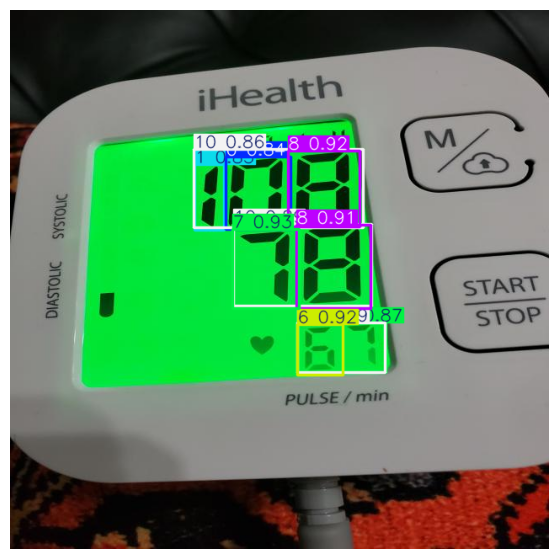

SYS = 108, DIA = 78, PUL = 67
Average Confidence = 0.89


In [11]:
# Load models
MODEL_PATH = '/path/to/model' #SMART-BP_Weights.pt

model = YOLO(MODEL_PATH)

img_path = '/path/to/BP/image/'

identifyResult(img_path, model)